+---------+----------+--------------+--------------+----------+--------------+--------------+----------+--------------+--------------+----------+--------------+--------------+----------+--------------------+--------------------+----------+--------------+--------------+----------+--------------+--------------+----------+--------------+--------------+----------+--------------------+--------------------+----------+--------------------+--------------------+----------+--------------------+--------------------+----------+--------------------+--------------------+----------+-----------+-------+
|hbfNumber|dc31_x1_id|dc31_x1_timing|dc31_x1_charge|dc31_x2_id|dc31_x2_timing|dc31_x2_charge|dc31_y1_id|dc31_y1_timing|dc31_y1_charge|dc31_y2_id|dc31_y2_timing|dc31_y2_charge|dc31_x3_id|      dc31_x3_timing|      dc31_x3_charge|dc31_x4_id|dc31_x4_timing|dc31_x4_charge|dc31_y3_id|dc31_y3_timing|dc31_y3_charge|dc31_y4_id|dc31_y4_timing|dc31_y4_charge|dc32_x1_id|      dc32_x1_timing|      dc32_x1_charge|d

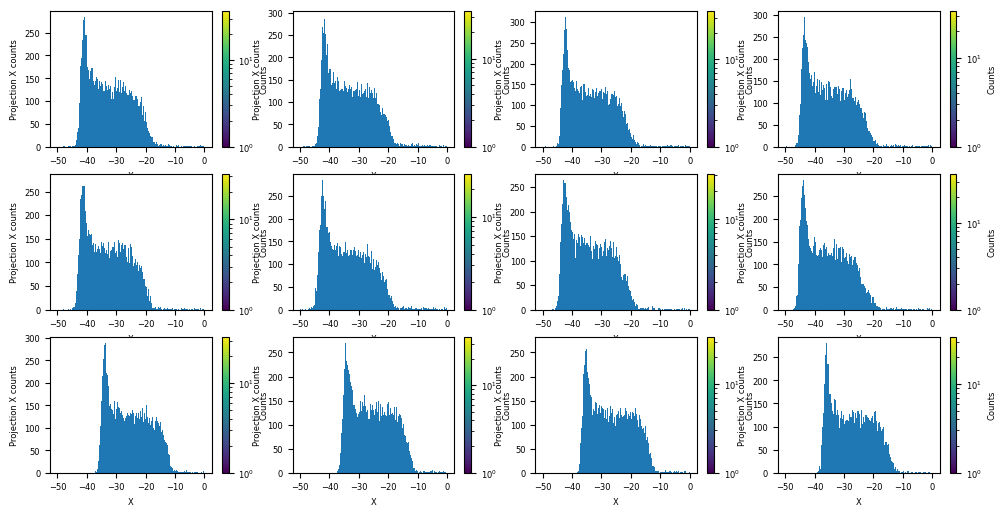

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from matplotlib import pyplot as plt
from hist.sparkHist2d import Hist2D
from hist.projection import ProjectionX
from matplotlib.colors import LogNorm


from make_MWDC_prm import drift_calib_data

#spark = SparkSession.builder.getOrCreate()
spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/notebooks/jan2026/mwdc/parquet/run1078_mwdc_koji.parquet")
df.show(5)
print(df.count())
runname = df.select("runname").collect()[0][0]

planes = ['dc31_x1','dc31_x2','dc31_y1','dc31_y2','dc31_x3','dc31_x4','dc31_y3','dc31_y4','dc32_x1','dc32_x2','dc32_y1','dc32_y2']
dc31_charge_range = [10,120]
dc31_timing_range = [-60,0]
dc32_charge_range = [10,120]
dc32_timing_range = [-60,0]

plt.figure(0, figsize=(12,6))
plt.rcParams["font.size"] = 6
for i, plane in enumerate(planes):
    q, mod = divmod(i,4)
    ax =plt.subplot2grid((3,4),(q,mod))
    dfp = df.select(f"{plane}_id",f"{plane}_charge",f"{plane}_timing")
    dfp = dfp.withColumn("charge0",F.expr(f"element_at({plane}_charge, 1)")) \
             .withColumn("timing0",F.expr(f"element_at({plane}_timing,1)")) \
             .withColumn("id0",F.expr(f"element_at({plane}_id, 1)")) 
    dfp = dfp.filter("id0>0 and id0<15")

    if "dc31" in plane:
        charge_range = dc31_charge_range
        timing_range = dc31_timing_range
    else:
        charge_range = dc32_charge_range
        timing_range = dc32_timing_range
    dfp = dfp.filter(F.expr(f"charge0 > {charge_range[0]} and charge0 < {charge_range[1]} and timing0 > {timing_range[0]} and timing0 < {timing_range[1]}"))
    H, xedges, yedges = Hist2D(dfp, ["timing0","charge0"],[250,250],[[-50,0],[20,120]],  interpolation='none', norm=LogNorm())
    ax.clear()
    Hpr, xedges_pr = ProjectionX(H, xedges, yedges)
    print(xedges_pr[0],xedges_pr[-1],len(xedges_pr))
    drift_calib_data(Hpr, f"/home/h487/notebooks/jan2026/kojima/mwdc_koji/prm/{plane}_drift_calib_data_{runname}.csv", h_range=(int(xedges_pr[0]), int(xedges_pr[-1])), nbin=len(xedges_pr)-1)
plt.show()